In [1]:
import pandas as pd

file_path = 'df_bal_binario.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda,y_bin,classe_risco_qualificacao
0,8434788,736.0,2,43,20008,0,4,1,1,1,...,0.0,0,0,0.000000,0.000000,0.250000,0.000000,2,1,renda formal per capita (CNIS) > ½ SM
1,2401972,0.0,2,26,708,0,4,1,1,1,...,0.0,0,0,0.285714,0.142857,0.142857,0.285714,0,0,renda formal per capita (CNIS) ≤ ½ SM
2,8872561,2026.0,2,50,5400,0,1,1,1,1,...,0.0,0,0,0.000000,0.000000,0.000000,0.000000,2,1,renda formal per capita (CNIS) > ½ SM
3,4265969,1379.0,2,31,65552,0,1,1,1,2,...,0.0,0,0,0.000000,0.000000,0.000000,0.000000,2,1,renda formal per capita (CNIS) > ½ SM
4,5921492,257.0,2,35,52403,0,2,1,1,1,...,0.0,0,0,0.000000,0.000000,0.500000,0.000000,1,0,renda formal per capita (CNIS) ≤ ½ SM


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 54 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   VL_RENDA_MEDIA_FAM            1000000 non-null  float64
 2   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 3   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 4   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 5   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 6   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 7   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 8   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 9   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 10  QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 11  QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 12  CO_MATERIAL_DOMIC_FAM        

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [4]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: classe_renda
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [5]:
df['y_bin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: y_bin
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


## Separação treino e teste

In [6]:
df["ID_FAM_ANON"].is_unique

True

In [7]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [21]:
colunas_excluir = [
    "classe_renda",
    "y_bin",
    "classe_risco_qualificacao",
    "VL_RENDA_MEDIA_FAM",
    "ID_FAM_ANON"
]

X = df.drop(columns=colunas_excluir)
y = df["y_bin"]


In [9]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [10]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1

## Análise de correlação das variáveis

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
    'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
    'PCT_MENOR6_FORA_CRECHE_PRE', 
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

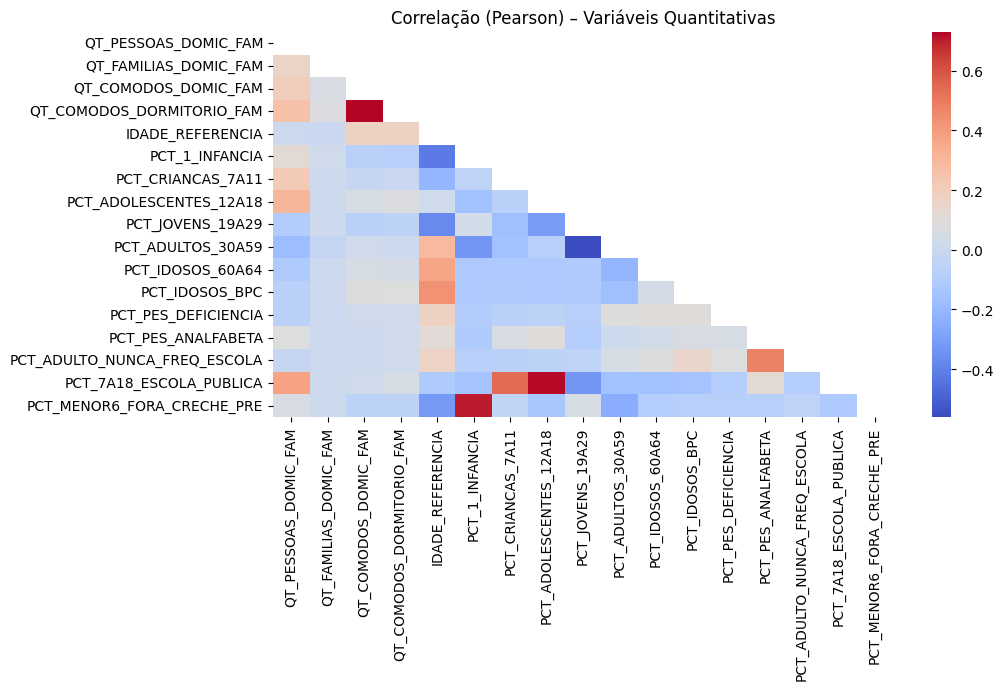

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = X[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [13]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
31,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.729839
98,PCT_ADOLESCENTES_12A18,PCT_7A18_ESCOLA_PUBLICA,0.717960
80,PCT_1_INFANCIA,PCT_MENOR6_FORA_CRECHE_PRE,0.702033
100,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.561260
89,PCT_CRIANCAS_7A11,PCT_7A18_ESCOLA_PUBLICA,0.543187
130,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,0.476326
64,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.427704
58,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.419325
14,QT_PESSOAS_DOMIC_FAM,PCT_7A18_ESCOLA_PUBLICA,0.381982
61,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.370786


In [14]:
THR_CORR = 0.80

corr_fortes = corr_pairs_sorted[
    corr_pairs_sorted["corr"].abs() >= THR_CORR
].copy()

corr_fortes

,var1,var2,corr


In [15]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


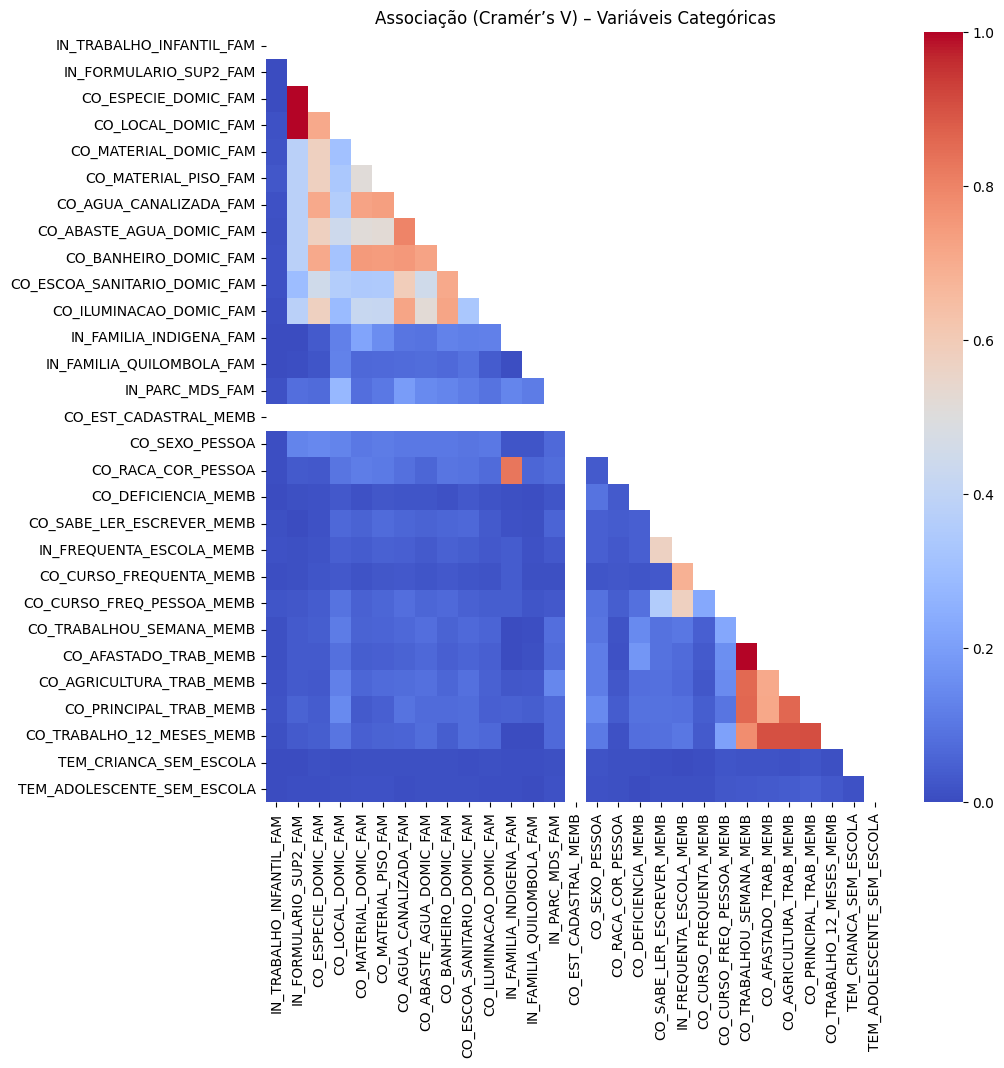

In [16]:
# Selecionar todas as categóricas
df_cat = X[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [17]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999797
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999797
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.909984
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.904556
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.903191
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.860352
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.860126
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.857222
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.829786


In [18]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999797
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999797
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.909984
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.904556
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.903191
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.860352
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.860126
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.857222
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.829786
147    CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.800315


In [22]:
X = X.drop(columns=['IN_FORMULARIO_SUP2_FAM', 'CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM', 'CO_AGUA_CANALIZADA_FAM'])

In [23]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64', 'PCT_IDOSOS_BPC',
    

In [24]:
X.head()

,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,CO_MATERIAL_DOMIC_FAM,...,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE
0,2,43,20008,4,1,1,1,6,3,1,...,0.500000,0.0,0.0,0.0,0,0,0.000000,0.000000,0.250000,0.000000
1,2,26,708,4,1,1,1,5,2,1,...,0.428571,0.0,0.0,0.0,0,0,0.285714,0.142857,0.142857,0.285714
2,2,50,5400,1,1,1,1,4,1,1,...,0.000000,0.0,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000
3,2,31,65552,1,1,1,2,7,1,1,...,0.000000,0.0,0.0,0.0,0,0,0.000000,0.000000,0.000000,0.000000
4,2,35,52403,2,1,1,1,5,2,1,...,0.500000,0.0,0.0,0.0,0,0,0.000000,0.000000,0.500000,0.000000


In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 44 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 1   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 2   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 3   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 4   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 5   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 6   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 7   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 8   QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 9   CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 10  CO_MATERIAL_PISO_FAM          1000000 non-null  int64  
 11  CO_ABASTE_AGUA_DOMIC_FAM      1000000 non-null  int64  
 12  CO_BANHEIRO_DOMIC_FAM        

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [26]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64', 'PCT_IDOSOS_BPC',
    

In [27]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 
    'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 
    'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
         'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
      'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
      'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
      'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'QTD_PESSOAS', 'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']


In [28]:
# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB', 'CO_TRABALHO_12_MESES_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB']


In [29]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [30]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [31]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [32]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [33]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [34]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [35]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [37]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM', 'QTD_PESSOAS',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADOLESCENTES_12A18', 'PCT...
                                  'CO_MATERIAL_PISO_FAM',
                                  'CO_ABASTE_AGUA_DOMIC_FAM',
                                  'CO_BANHEIRO_DOMIC_FAM',
                                  'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                  'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM',
                                  'CO_RACA_COR_PESSOA',
                                  'IN_FREQUENTA_ESCOLA_MEMB',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB',
                                  'CO_AFASTADO_TRAB_MEMB',
                                  'CO_PRINCIPAL_TRAB_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [38]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__QTD_PESSOAS,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,...,multicat__CO_PRINCIPAL_TRAB_MEMB_4,multicat__CO_PRINCIPAL_TRAB_MEMB_5,multicat__CO_PRINCIPAL_TRAB_MEMB_6,multicat__CO_PRINCIPAL_TRAB_MEMB_7,multicat__CO_PRINCIPAL_TRAB_MEMB_8,multicat__CO_PRINCIPAL_TRAB_MEMB_9,multicat__CO_PRINCIPAL_TRAB_MEMB_10,multicat__CO_PRINCIPAL_TRAB_MEMB_11,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.032967,0.02,0.065934,0.042254,0.076923,0.477273,0.0,0.0,0.00,0.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,5500.0
1,0.043956,0.02,0.032967,0.042254,0.000000,0.056818,0.0,0.0,0.00,1.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,154.0
2,0.065934,0.02,0.065934,0.042254,0.307692,0.079545,0.4,0.2,0.00,0.40,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,30607.0
3,0.043956,0.02,0.098901,0.056338,0.153846,0.681818,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.0,1408.0
4,0.054945,0.02,0.076923,0.056338,0.230769,0.397727,0.0,0.0,0.25,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,1109.0


### Comparando diversos modelos

In [39]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ------------------------------------------------------------
# 0) CONFIG DE TRIAGEM
# ------------------------------------------------------------
SEED = 42
THRESHOLD_TRIAGEM = 0.80  # ajuste depois conforme capacidade operacional
POS_LABEL = 1             # 1 = acima de 1/2 SM (potencialmente não elegível)


# ------------------------------------------------------------
# 1) MODELOS (ajustados para BINÁRIO)
# ------------------------------------------------------------
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        random_state=SEED
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced"  # ajuda quando há desbalanceamento
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=1200,          # mais árvores + taxa menor costuma ajudar
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1
        # (opcional) scale_pos_weight pode ser ajustado se a classe 1 for rara
    ),

    "CatBoost": CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False
        # (opcional) class_weights=[w0, w1] se necessário
    ),
}


# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO (com métricas para TRIAGEM)
# ------------------------------------------------------------
pipes = {}
results = []

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    # Predição padrão (threshold 0.5)
    y_pred_05 = pipe.predict(X_test).ravel()

    # Probabilidades (para AUC/PR-AUC e para threshold de triagem)
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    # Predição para TRIAGEM (threshold configurável)
    if y_proba is not None:
        y_pred_t = (y_proba >= THRESHOLD_TRIAGEM).astype(int)
    else:
        y_pred_t = y_pred_05  # fallback

    # -------------------------
    # Métricas: padrão 0.5
    # -------------------------
    acc_05 = accuracy_score(y_test, y_pred_05)
    balacc_05 = balanced_accuracy_score(y_test, y_pred_05)

    prec_05 = precision_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    rec_05  = recall_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    f1_05   = f1_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)

    tn05, fp05, fn05, tp05 = confusion_matrix(y_test, y_pred_05, labels=[0, 1]).ravel()

    # -------------------------
    # Métricas: TRIAGEM (threshold = THRESHOLD_TRIAGEM)
    # -------------------------
    acc_t = accuracy_score(y_test, y_pred_t)
    balacc_t = balanced_accuracy_score(y_test, y_pred_t)

    prec_t = precision_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    rec_t  = recall_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    f1_t   = f1_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)

    tnt, fpt, fnt, tpt = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()

    # -------------------------
    # AUC / PR-AUC (se houver proba)
    # -------------------------
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)  # PR-AUC (muito útil p/ triagem)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    # "Taxa de convocação" no teste (volume relativo gerado pela regra)
    convoc_rate = float(np.mean(y_pred_t == 1))

    results.append({
        "modelo": name,

        # Ranking mais aderente ao objetivo de triagem
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,

        # Métricas com threshold padrão
        "acc@0.50": acc_05,
        "bal_acc@0.50": balacc_05,
        "prec_pos@0.50": prec_05,
        "rec_pos@0.50": rec_05,
        "f1_pos@0.50": f1_05,
        "tp@0.50": tp05, "fp@0.50": fp05, "fn@0.50": fn05, "tn@0.50": tn05,

        # Métricas para a regra operacional de triagem
        f"acc@{THRESHOLD_TRIAGEM:.2f}": acc_t,
        f"bal_acc@{THRESHOLD_TRIAGEM:.2f}": balacc_t,
        f"prec_pos@{THRESHOLD_TRIAGEM:.2f}": prec_t,
        f"rec_pos@{THRESHOLD_TRIAGEM:.2f}": rec_t,
        f"f1_pos@{THRESHOLD_TRIAGEM:.2f}": f1_t,
        f"tp@{THRESHOLD_TRIAGEM:.2f}": tpt, f"fp@{THRESHOLD_TRIAGEM:.2f}": fpt,
        f"fn@{THRESHOLD_TRIAGEM:.2f}": fnt, f"tn@{THRESHOLD_TRIAGEM:.2f}": tnt,

        # volume gerado
        f"taxa_convocacao@{THRESHOLD_TRIAGEM:.2f}": convoc_rate,
    })


# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = (
    pd.DataFrame(results)
      .sort_values(["pr_auc", "roc_auc"], ascending=False)
      .reset_index(drop=True)
)

df_results



Treinando modelo: LogisticRegression

Treinando modelo: RandomForest

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,pr_auc,roc_auc,acc@0.50,bal_acc@0.50,prec_pos@0.50,rec_pos@0.50,f1_pos@0.50,tp@0.50,fp@0.50,...,acc@0.80,bal_acc@0.80,prec_pos@0.80,rec_pos@0.80,f1_pos@0.80,tp@0.80,fp@0.80,fn@0.80,tn@0.80,taxa_convocacao@0.80
0,XGBoost,0.823843,0.831502,0.747875,0.747875,0.731536,0.78316,0.756468,78316,28741,...,0.633835,0.633835,0.894177,0.30360,0.453293,30360,3593,69640,96407,0.169765
1,CatBoost,0.821393,0.829685,0.746820,0.746820,0.732284,0.77811,0.754502,77811,28447,...,0.628480,0.628480,0.895129,0.29106,0.439283,29106,3410,70894,96590,0.162580
2,HistGradientBoosting,0.819400,0.827963,0.745090,0.745090,0.728509,0.78137,0.754014,78137,29119,...,0.625505,0.625505,0.893914,0.28481,0.431985,28481,3380,71519,96620,0.159305
3,RandomForest,0.792431,0.808126,0.731895,0.731895,0.724711,0.74788,0.736113,74788,28409,...,0.629540,0.629540,0.853259,0.31289,0.457877,31289,5381,68711,94619,0.183350
4,LogisticRegression,0.785980,0.799671,0.723210,0.723210,0.727015,0.71483,0.720871,71483,26841,...,0.619055,0.619055,0.854193,0.28712,0.429779,28712,4901,71288,95099,0.168065


#### Os resultados indicam que o treinamento do modelo em uma base amostral proporcional à distribuição real das classes apresenta melhor alinhamento com o objetivo de apoiar a qualificação cadastral. Embora a amostragem balanceada permita maior sensibilidade a padrões estatísticos, ela distorce a prevalência observada no Cadastro Único, comprometendo a interpretação probabilística e a definição de limiares operacionais. A base proporcional preserva a calibragem das probabilidades estimadas e possibilita a definição de thresholds que equilibram precisão elevada — reduzindo a sobrecarga administrativa — e cobertura suficiente para identificação de famílias com maior risco de inconsistência de renda, em consonância com a literatura sobre focalização e uso de aprendizado de máquina em políticas sociais.